# Projeto 4 - Álgebra Linear Numérica

# Questão 1

## Item a)
Para obtermos um vetor na direção de $e_1$ com a mesma norma de $x$, queremos refletir $x$ pelo hiperplano ortogonal a $v = x - \lVert x \rVert e_1$, porque esse hiperplano é a mediatriz de $x$ e $e_1$. 

Nesse caso, a lógica para refletir é a mesma que para projetar! Se nosso projetor  $I - \frac{vv*}{v*v}$ projeta sobre o espaço ortogonal, então subtrair $\frac{vv*}{v*v}x$ de $x$ leva ao espaço ortogonal e, portanto, subtrair $2\frac{vv*}{v*v}x$ "atravessa" esse espaço e chega "do outro lado", na reflexão de $x$ pelo hiperplano. Essa reflexão é, justamente, o vetor $||x||e_1$. Assim, nosso refletor será $Q_v = I - \beta v v^*$.

Determinamos $\beta$ impondo $Q_v x = \lVert x \rVert e_1$:

$$
(I - \beta v v^*) x = \lVert x \rVert e_1
\implies x - \beta v (v^* x) = \lVert x \rVert e_1
\implies \beta (v^* x)\, v = x - \lVert x \rVert e_1 = v
$$

Como $v \neq 0$, concluímos que $\beta v^* x = 1$, e portanto:

$$
\beta = \frac{1}{v^* x} = \frac{1}{(x - \lVert x \rVert e_1)^* x} = \frac{1}{x^*x - \lVert x \rVert e_1^* x} = \frac{1}{\lVert x \rVert^2 - \lVert x \rVert x_1} = \frac{1}{\lVert x \rVert(\lVert x \rVert - x_1)}
$$

# Item b)

No caso em que $x_1$ é positivo, podemos enfrentar problemas ao computar $\frac{1}{\lVert x \rVert(\lVert x \rVert - x_1)}$ porque, se $x$ for muito próximo de $e_1$, $x_1 \approx \lVert x \rVert$ e o termo $\lVert x \rVert - x_1$ pode ficar muito próximo de $0$, o que faria com que $\beta$ "explodisse". Nesse caso, não enfrentamos o mesmo problema com a fórmula $\frac{\lVert x \rVert + x_1}{\lVert x \rVert \cdot \lVert y \rVert}$ porque estamos somando apenas quantidades positivas! 

O exato oposto é válido quando $x$ é negativo: $x$ muito próximo de $e_1$ torna $- x_1 \approx \lVert x \rVert$ e o termo $\lVert x \rVert + x_1$ pode ficar muito próximo de $0$, causando erros para $\frac{\lVert x \rVert + x_1}{\lVert x \rVert \cdot \lVert y \rVert}$, mas não enfrentamos esse problema computando  $\frac{1}{\lVert x \rVert(\lVert x \rVert - x_1)}$

## Item c)

In [ ]:
using LinearAlgebra

In [ ]:
function reflector(x::AbstractVector{T}) where T<:AbstractFloat
    v = copy(x)
    nrm = norm(x)

    if nrm ≈ 0
        return v, zero(T)
    end

    v[1] -= nrm
    
    if x[1] >= 0
        nrm_resto = norm(@view x[2:end])
        if nrm_resto ≈ 0
            return v, zero(T)
        end
        beta = (nrm + x[1]) / (nrm * nrm_resto ^ 2)
    else
        beta = one(T) / (nrm * (nrm - x[1]))
    end

    return v, beta
end

@time reflector([0, 0, 0])

  0.000007 seconds (5 allocations: 208 bytes)


([0.0, 0.0, 0.0], 0.0)

## Item d)

O vetor $v$ é definido como:

$$
v = \begin{bmatrix}
x_1 - \lVert x \rVert \\[0.8em]
x_2 \\
x_3 \\
\vdots \\
x_n
\end{bmatrix}
$$

Calculamos o Jacobiano $J = \frac{\partial v}{\partial x}$. Para isso, usamos que:

$$
\frac{\partial \lVert x \rVert}{\partial x_i} = \frac{\partial \sqrt{x_1^2 + \dots + x_n^2}}{\partial x_i} = \frac{x_i}{\lVert x \rVert}, \qquad i = 1, \dots, n
$$

Portanto:

$$
J = \begin{bmatrix}
1 - \dfrac{x_1}{\lVert x \rVert} & -\dfrac{x_2}{\lVert x \rVert} & \cdots & -\dfrac{x_n}{\lVert x \rVert} \\[1.2em]
0 & 1 & \cdots & 0 \\[0.8em]
\vdots & \vdots & \ddots & \vdots \\[0.8em]
0 & 0 & \cdots & 1
\end{bmatrix}
$$

Fatorando, reconhecemos que $J$ pode ser escrito como:

$$
J = I - \frac{1}{\lVert x \rVert}
\begin{bmatrix}
x_1 & x_2 & \cdots & x_n \\[0.8em]
0 & 0 & \cdots & 0 \\[0.8em]
\vdots & \vdots & \ddots & \vdots \\[0.8em]
0 & 0 & \cdots & 0
\end{bmatrix}
= I - \frac{e_1 x^*}{\lVert x \rVert}
$$

Sabe-se que o condicionamento absoluto de $v$ em relação a $x$ se dá por $\hat{\kappa} = \lVert J \rVert$, assim:
$$
\hat{\kappa} = \lVert J \rVert = \lVert I - \frac{e_1 x^*}{\lVert x \rVert} \rVert \leq \lVert I \rVert + \lVert - \frac{e_1 x^*}{\lVert x \rVert} \rVert = 1 + \frac{1}{\lVert x \rVert}\lVert e_1 x^*\rVert \leq 1 + \frac{1}{\lVert x \rVert}\lVert e_1 \rVert \lVert x^* \rVert = 2
$$
Ou seja, o condicionamento absoluto de $v$ em relação a $x$ é $\hat{\kappa} \leq 2$.

## Item e)

In [ ]:
for n in [2, 10, 100, 1000, 100_000, 1_000_000]
    x64 = Float64.(rand(n))
    target64 = zeros(n)
    target64[1] = norm(x64)
    target32 = zeros(n)
    target32[1] = norm(x32)
    x32 = Float32.(x64)
    v64, beta64 = reflector(x64)
    v32, beta32 = reflector(x32)
    @show n norm(v32 - v64) norm(beta32 - beta64)
    r32 = Refletores(v32, beta32)
    r64 = Refletores(v64, beta64)
    result32 = apply_reflector(r32, x32)
    @show norm(result32 - target32) norm()
end

n = 2
norm(v32 - v64) = 4.88641434576246e-8
norm(beta32 - beta64) = 8.012329431039689e-7


MethodError: MethodError: no method matching apply_reflector()
The function `apply_reflector` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  apply_reflector(!Matched::Any, !Matched::Any)
   @ Main ~/Downloads/Fgv/ALN/aln-projeto-04/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X31sZmlsZQ==.jl:1


A princípio, vemos que os valores de $v$ ficam progressivamente mais distantes e que os valores de $\beta$ ficam progressivamente mais próximos à medida em que $n$ aumenta!

## Item f)

In [ ]:
function calc_beta(v::Vector{T}) where T<:AbstractFloat
    return 2/norm(v)^2
end

calc_beta (generic function with 1 method)

In [281]:
#TODO: REPETIR OS TESTES


In [ ]:
for n in [2, 10, 100, 10000]
    @show n
    for k in 1:3:10
        x = rand(n)
        x[2:end] .*= 10.0^-k
        v, beta = reflector(x)
        beta_v = calc_beta(v)
        @show k norm(beta - beta_v)
    end
end


n = 2
k = 1
norm(beta - beta_v) = 0.0
k = 4
norm(beta - beta_v) = 4.76837158203125e-7
k = 7
norm(beta - beta_v) = 0.0
k = 10
norm(beta - beta_v) = 0.0
n = 10
k = 1
norm(beta - beta_v) = 0.0
k = 4
norm(beta - beta_v) = 2.9802322387695312e-8
k = 7
norm(beta - beta_v) = 0.015625
k = 10
norm(beta - beta_v) = 8192.0
n = 100
k = 1
norm(beta - beta_v) = 0.0
k = 4
norm(beta - beta_v) = 9.313225746154785e-10
k = 7
norm(beta - beta_v) = 0.0009765625
k = 10
norm(beta - beta_v) = 0.0
n = 10000
k = 1
norm(beta - beta_v) = 6.938893903907228e-18
k = 4
norm(beta - beta_v) = 7.275957614183426e-12
k = 7
norm(beta - beta_v) = 1.52587890625e-5
k = 10
norm(beta - beta_v) = 16.0


## Item g)

In [277]:
for n in [2, 10, 100, 1000]
    @show n
    for k in 1:3:16
        x = rand(n)
        x[2:end] .*= 10.0^-k
        v, beta = reflector(x)
        e_1 = zeros(n)
        e_1[1]=1
        J = I -( e_1 * x')/norm(x)
        @show k norm(J)
    end
end


n = 2
k = 1
norm(J) = 1.0000793044027219
k = 4
norm(J) = 1.0000000000832887
k = 7
norm(J) = 1.0000000000000029
k = 10
norm(J) = 1.0
k = 13
norm(J) = 1.0
k = 16
norm(J) = 1.0
n = 10
k = 1
norm(J) = 3.0612946585676526
k = 4
norm(J) = 3.0000000143558925
k = 7
norm(J) = 3.0000000000000213
k = 10
norm(J) = 3.0
k = 13
norm(J) = 3.0
k = 16
norm(J) = 3.0
n = 100
k = 1
norm(J) = 9.972170846994093
k = 4
norm(J) = 9.949874423398203
k = 7
norm(J) = 9.94987437106623
k = 10
norm(J) = 9.9498743710662
k = 13
norm(J) = 9.9498743710662
k = 16
norm(J) = 9.9498743710662
n = 1000
k = 1
norm(J) = 31.625762370209028
k = 4
norm(J) = 31.606961312511253
k = 7
norm(J) = 31.606961258558275
k = 10
norm(J) = 31.606961258558215
k = 13
norm(J) = 31.606961258558215
k = 16
norm(J) = 31.606961258558215


# Questão 2

## Item a)

In [ ]:
struct Refletores{T<:Number}
    v::Vector
    beta::T
    dim::Int

    function Refletores(v::Vector, beta::T) where {T<:Number}
        dim = length(v)
        new{T}(v, beta, dim)
    end
    
end

r = Refletores([1, 0, 0], 2)
r.dim

3

In [ ]:
function apply_reflector!(ref::Refletores, b::Vector)
    @views b[1:ref.dim] .-= ref.beta .* ref.v .*(ref.v ⋅ b[1:ref.dim])
    return b
end

apply_reflector! (generic function with 1 method)

## Item b)

Para testar nossa função, vamos comparar os resultados de `apply_reflector` com o alvo $\lVert x \rVert e_1$

In [ ]:
for i in 2:100:1000
    b = rand(i)
    target = zeros(i)
    target[1] = norm(b)
    v, beta = reflector(b)
    r = Refletores(v, beta)
    apply_reflector!(r, b)
    println("i = ", i, ", norma = ", norm(target - b))
end

for i in 2:100:1000
    for j in i:10:(i+100)
        b = rand(j)
        target = copy(b)
        target[2:i] .= 0
        target[1] = norm(b[1:i])
        v, beta = reflector(b[1:i])
        r = Refletores(v, beta)
        apply_reflector!(r, b)
        println("i = ", i, ", j = ", j, ", norma = ", norm(target - b))
    end
end


i = 2, norma = 0.0
i = 102, norma = 5.822058759297239e-16
i = 202, norma = 9.554027931413695e-16
i = 302, norma = 3.2699721577186038e-15
i = 402, norma = 1.845761266976801e-15
i = 502, norma = 7.154993099982488e-16
i = 602, norma = 1.979984529070768e-15
i = 702, norma = 2.0672584009808127e-15
i = 802, norma = 5.6898746143654966e-15
i = 902, norma = 1.018514455409224e-14
i = 2, j = 2, norma = 0.0
i = 2, j = 12, norma = 5.551115123125783e-17
i = 2, j = 22, norma = 3.3306690738754696e-16
i = 2, j = 32, norma = 1.5700924586837752e-16
i = 2, j = 42, norma = 0.0
i = 2, j = 52, norma = 2.7755575615628914e-16
i = 2, j = 62, norma = 1.1102230246251565e-16
i = 2, j = 72, norma = 3.510833468576701e-16
i = 2, j = 82, norma = 1.5700924586837752e-16
i = 2, j = 92, norma = 1.5700924586837752e-16
i = 2, j = 102, norma = 9.777686967753793e-16
i = 102, j = 102, norma = 1.3633204974290346e-15
i = 102, j = 112, norma = 2.5452242591958667e-15
i = 102, j = 122, norma = 1.378607568032133e-15
i = 102, j = 132

Vemos que, em todos os casos, obtemos um erro de ordem $\leq 10^{14}$

Já para verificar a complexidade computacional, vamos testar para vetores cada vez maiores e observar como o tempo de execução cresce!

In [ ]:
using BenchmarkTools, Plots

In [282]:
sizes = 1000:2000:50_000
times = zeros(length(sizes))

for (k, i) in enumerate(sizes)
    b = rand(i)
    v, beta = reflector(b)
    r = Refletores(v, beta)
    
    times[k] = @belapsed apply_reflector!($r, b_copy) setup=(b_copy=copy($b))
end

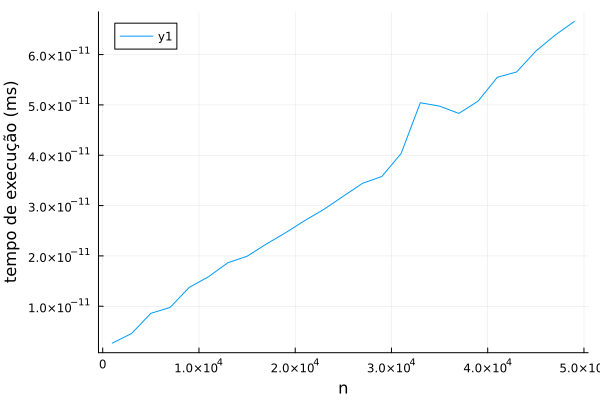

In [283]:
plot(sizes, times ./ 1e6, xlabel="n", ylabel="tempo de execução (ms)")

De fato, o tempo de execução cresce de maneira essencialmente linear, indicando uma complexidade $O(n)$

## Item c)

In [ ]:
function apply_reflector(ref, A)
    A = float(copy(A))
    start = size(A, 1)-ref.dim+1
    A[start:end, :] .-= ref.beta .* ref.v .* (ref.v' * A[start:end, :])
    return A
end


apply_reflector (generic function with 1 method)

## Item d)

In [ ]:
function rev_apply_reflector(ref, A)
    A = float(copy(A))
    start = size(A, 2)-ref.dim+1
    A[:, start:end] .-= ref.beta .* (A[:, start:end]*ref.v) .*ref.v'
    return A
end


rev_apply_reflector (generic function with 1 method)

In [279]:
a = [1 2 3; 2 5 6; 0 6 9]
v, beta = reflector(a[2:end,1])
r = Refletores(v, beta)
a = apply_reflector(r, a)
a = rev_apply_reflector(r, a)




3×3 Matrix{Float64}:
 1.0  2.0  3.0
 2.0  5.0  6.0
 0.0  6.0  9.0

## Item e)

In [ ]:
function to_hessemberg(A; return_q=false)
    A = float(copy(A))
    reflectors = []
    n = size(A, 1)
    for i in 1:(n-2)
        v, beta = reflector(A[(i+1):end, i])
        r = Refletores(v, beta)
        push!(reflectors, r)
        A = apply_reflector(r, A)
        A = rev_apply_reflector(r, A)
    end
    if return_q
        Q = Matrix(1.0*I, n, n)
        for r in reflectors
            Q = rev_apply_reflector(r, Q)
        end
        return A, reflectors, Q
    end

    return A, reflectors
end



to_hessemberg (generic function with 2 methods)

## Item f)

In [ ]:
sizes = [2, 10, 100]
for n in sizes
    @show n
    A = rand(n, n)*10
    H, ref, Q = to_hessemberg(A, return_q=true)
    @show norm(A - Q*H*Q')

    S = A'A
    Hs, ref, Qs = to_hessemberg(S, return_q=true)
    @show norm(S - Qs*Hs*Qs')
end

n = 2
norm(A - Q * H * Q') = 0.0
norm(S - Qs * Hs * Qs') = 0.0
n = 10
norm(A - Q * H * Q') = 1.7958350753660174e-14
norm(S - Qs * Hs * Qs') = 5.465177685843347e-13
n = 100
norm(A - Q * H * Q') = 4.420551481523632e-13
norm(S - Qs * Hs * Qs') = 1.7555088431996946e-10


# Questão 3

## Item a)

Os autovalores de $A$ são as raízes do polinômio característico:

$$
\det(A - \lambda I) = \lambda^2 + \omega^2 = 0 \implies \lambda_1 = i\omega, \qquad \lambda_2 = -i\omega
$$

Para os autovetores, resolvemos $(A - \lambda_k I)q_k = 0$ para cada autovalor.

Para $\lambda_1 = i\omega$:

$$
\begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix} \begin{bmatrix} a \\ c \end{bmatrix} = i\omega \begin{bmatrix} a \\ c \end{bmatrix} \implies c = i\omega a
$$

Para $\lambda_2 = -i\omega$:

$$
\begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix} \begin{bmatrix} b \\ d \end{bmatrix} = -i\omega \begin{bmatrix} b \\ d \end{bmatrix} \implies d = -i\omega b
$$

Escolhendo $a = b = 1$, a matriz de autovetores é:

$$
Q = \begin{bmatrix} 1 & 1 \\ i\omega & -i\omega \end{bmatrix}
$$

Ou seja, os autovetores são:

$$
x_1 = \begin{bmatrix} 1 \\ i\omega \end{bmatrix}, x_2 = \begin{bmatrix} 1 \\ -i\omega \end{bmatrix}
$$

Quando $\omega \to 0$, os autovalores $\lambda_{1,2} = \pm i\omega \to 0$ coincidem, e os autovetores $x_1, x_2 \to \begin{bmatrix} 1 \\ 0 \end{bmatrix}$ também coincidem. Nesse limite, $A$ deixa de ser diagonalizável.

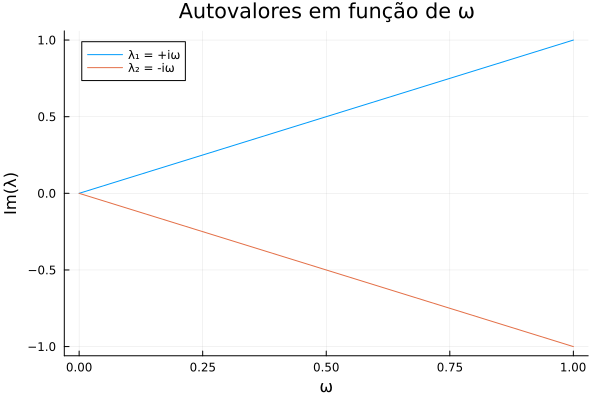

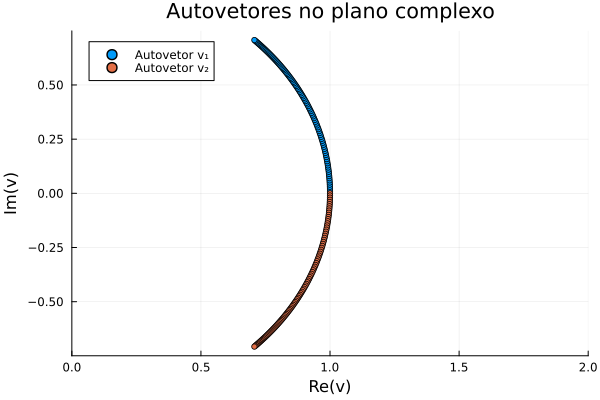

In [ ]:
omega_vals = (0:100) / 100
egvln = []
egvlp = []
egvtn = []
egvtp = []

for omega in omega_vals
    A = [  0        1
          -omega^2  0]

    evls = eigvals(A)
    evts = eigvecs(A)

    push!(egvln, evls[1])
    push!(egvlp, evls[2])
    push!(egvtn, evts[:, 1])
    push!(egvtp, evts[:, 2])
end

xs_p = [v[1] for v in egvtp]
ys_p = [v[2] for v in egvtp]
xs_n = [v[1] for v in egvtn]
ys_n = [v[2] for v in egvtn]

p1 = plot(omega_vals, imag.(egvlp),
    label = "λ₁ = +iω",
    xlabel = "ω",
    ylabel = "Im(λ)",
    title = "Autovalores em função de ω",
    legend = :topleft)
plot!(p1, omega_vals, imag.(egvln),
    label = "λ₂ = -iω")

p2 = scatter(real.(xs_p), imag.(ys_p),
    label = "Autovetor x₁",
    xlabel = "Re(v)",
    ylabel = "Im(v)",
    title = "Autovetores no plano complexo",
    legend = :topleft,
    markersize = 3)
scatter!(p2, real.(xs_n), imag.(ys_n),
    label = "Autovetor x₂",
    markersize = 3)
xlims!(p2, (0, 2))

display(p1)
display(p2)

## Item b)

$$
A^*A = \begin{bmatrix}
0 & -\omega^2 \\
1 & 0
\end{bmatrix} \begin{bmatrix}
0 & 1 \\
-\omega^2 & 0
\end{bmatrix} = \begin{bmatrix}
\omega^4 & 0 \\
0 & 1
\end{bmatrix}
$$

Os valores singulares de $A$ são as raízes quadradas dos autovalores de $A^*A$. Calculamos o polinômio característico:

$$
\det(A^*A - \lambda I) = (\omega^4 - \lambda)(1 - \lambda) = 0
\implies \lambda_1 = \omega^4, \quad \lambda_2 = 1
$$

Portanto, os valores singulares são:

$$
\sigma_1 = \sqrt{\lambda_1} = \omega^2, \qquad \sigma_2 = \sqrt{\lambda_2} = 1
$$

Como $\omega \in [0, 1]$, temos $\omega^2 \leq 1$, ou seja, $\sigma_1 \leq \sigma_2$. O número de condicionamento de $A$ é dado por:

$$
\kappa(A) = \frac{\sigma_{\max}}{\sigma_{\min}} = \frac{\sigma_2}{\sigma_1} = \frac{1}{\omega^2}
$$